# Тема 8. Градиентный бустинг

## Занятие 8 (теория) — финал курса

**В теме 5 случайный лес строил деревья независимо друг от друга** (каждое — на своей бутстрап-выборке, параллельно) и усреднял их голоса. Сегодня — другая идея: строить деревья **последовательно**, так, чтобы каждое новое дерево целенаправленно исправляло ошибки уже построенного ансамбля. Это и есть **градиентный бустинг** — один из самых сильных инструментов практического машинного обучения, основа большинства побед в соревнованиях по табличным данным.

**План занятия:** идея бустинга — учимся на остатках → скорость обучения (learning rate) → бустинг для классификации на данных оттока → XGBoost и другие реализации → ранняя остановка → финальный счёт за весь курс.

**Практика** — в `lesson08_gradient_boosting_practice.ipynb` (Titanic — последний раз сравниваем с деревом и лесом).
**Дополнительно** (важность признаков в XGBoost, `GridSearchCV` по нескольким параметрам сразу, стохастический бустинг) — в `lesson08_gradient_boosting_advanced.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Идея: учимся на остатках

Возьмём задачу регрессии — предсказать число по одному признаку (для классификации идея та же, но чуть сложнее формулами, к ней вернёмся в разделе 3). Обучим не одно дерево, а последовательность:

1. Первое дерево предсказывает `y` как обычно.
2. Считаем **остаток** (residual) — насколько первое дерево ошиблось: `residual = y - предсказание`.
3. Второе дерево обучаем **не на `y`, а на остатке** — то есть учим его предсказывать именно ошибку первого дерева.
4. Складываем предсказания: `первое дерево + второе дерево` — второе «подправляет» первое.
5. Повторяем: третье дерево учим на **новом** остатке (том, что осталось после первых двух), и так далее.

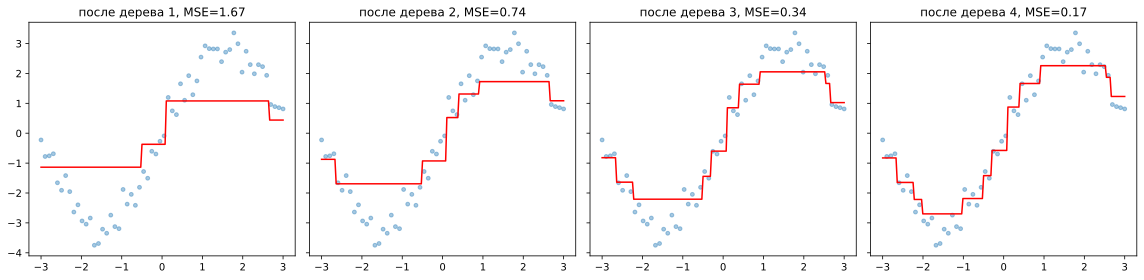

In [2]:
rng = np.random.RandomState(RANDOM_STATE)
X_toy = np.linspace(-3, 3, 60).reshape(-1, 1)
y_toy = np.sin(X_toy.ravel()) * 3 + rng.normal(0, 0.4, 60)
X_line = np.linspace(-3, 3, 200).reshape(-1, 1)

learning_rate = 0.5
prediction = np.zeros_like(y_toy)
prediction_line = np.zeros(len(X_line))

_, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i, ax in enumerate(axes):
    residual = y_toy - prediction
    tree = DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE)
    tree.fit(X_toy, residual)
    prediction = prediction + learning_rate * tree.predict(X_toy)
    prediction_line = prediction_line + learning_rate * tree.predict(X_line)

    ax.scatter(X_toy, y_toy, alpha=0.4, s=15)
    ax.plot(X_line, prediction_line, color="red")
    ax.set_title(f"после дерева {i + 1}, MSE={np.mean((y_toy - prediction) ** 2):.2f}")
plt.tight_layout();

С каждым добавленным деревом суммарное предсказание всё точнее следует за формой данных, а MSE падает. Ни одно дерево по отдельности не обучено предсказывать `y` целиком — каждое отвечает только за то, что не смогли предыдущие.

---
## 2. Скорость обучения (learning rate)

Обратите внимание на `learning_rate = 0.5` в коде выше — предсказание каждого дерева добавляется не целиком, а с этим множителем. Это главный регулятор переобучения в бустинге (аналог `max_depth` для одного дерева и `n_estimators`/`max_features` для леса):

- **Маленький `learning_rate`** (например, 0.01) — каждое дерево вносит небольшой вклад, нужно много деревьев (`n_estimators`), но итоговая модель обычно устойчивее и меньше переобучается.
- **Большой `learning_rate`** (например, 0.5-1.0) — модель обучается быстрее (меньше деревьев нужно), но легче переобучается — деревья слишком резко подстраиваются под остатки, включая шум.

На практике `learning_rate` и `n_estimators` подбирают вместе: чем меньше `learning_rate`, тем больше `n_estimators` нужно для того же качества.

---
## 3. Бустинг на данных оттока

Для классификации идея та же (последовательные деревья на «остатках»), но вместо прямого остатка `y - pred` используется градиент функции потерь (log loss из темы 4) — отсюда название **градиентный** бустинг. Технические детали за рамками занятия, интерфейс в sklearn — тот же, что у леса.

**Задание преподавателю на занятии:** обучите `GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)` на данных оттока (подготовка — как в темах 3-5), сравните `.score()` на valid с лесом (95.1%).

In [3]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)
X = df.drop(columns=["State", "Churn"])
y = df["Churn"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
# gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
# gbm.fit(X_train, y_train)
# gbm.score(X_valid, y_valid)


In [4]:
gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
gbm.fit(X_train, y_train)
round(gbm.score(X_valid, y_valid), 4)

0.956

**~95.6%** — на уровне леса (95.1%), иногда чуть выше. На этом конкретном датасете бустинг не даёт драматического отрыва — это честный, реалистичный результат: отток телекома относительно «лёгкая» задача, оба сильных ансамблевых метода упираются примерно в один и тот же потолок точности. Разрыв между бустингом и лесом обычно заметнее на более сложных/шумных задачах и больших данных — как раз там, где соревнования по ML чаще всего выигрывает именно бустинг.

---
## 4. XGBoost, LightGBM, CatBoost

`GradientBoostingClassifier` из sklearn — эталонная, но не самая быстрая реализация. На практике почти всегда используют одну из специализированных библиотек:

| Библиотека | Особенность |
|---|---|
| **XGBoost** | Первая широко популярная быстрая реализация, много готовых регуляризаций, стандарт де-факто |
| **LightGBM** | Строит деревья «по листьям», а не «по уровням» — быстрее на больших данных, меньше памяти |
| **CatBoost** | Специальная обработка категориальных признаков «из коробки» (не нужно заранее кодировать `International plan` в 0/1, как делаем мы) |

Все три относительно похожи по итоговому качеству на большинстве задач и заметно быстрее sklearn на больших датасетах; выбор часто определяется удобством, а не разницей в точности. Попробуем XGBoost — интерфейс намеренно похож на sklearn:

In [5]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE, eval_metric="logloss"
)
xgb_clf.fit(X_train, y_train)
round(xgb_clf.score(X_valid, y_valid), 4)

0.954

Практически идентичный результат — ожидаемо, обе библиотеки реализуют один и тот же алгоритм, разница в основном в скорости и деталях реализации, а не в итоговом качестве на этой задаче.

---
## 5. Ранняя остановка (early stopping)

Вместо того чтобы заранее гадать хорошее `n_estimators` (как мы перебирали `max_depth` в теме 3), можно взять заведомо большое число деревьев, но **следить за качеством на валидационной выборке по ходу обучения** и остановиться, как только оно перестанет расти:

In [6]:
xgb_es = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE,
    eval_metric="logloss", early_stopping_rounds=20,
)
xgb_es.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

print(f"Остановились на дереве №{xgb_es.best_iteration} из 1000 запрошенных")
print(f"Точность: {xgb_es.score(X_valid, y_valid):.4f}")

Остановились на дереве №160 из 1000 запрошенных
Точность: 0.9510


Экономит время (не считаем деревья, которые всё равно не улучшат результат) и заодно работает как регуляризация — не даёт модели продолжать подстраиваться под обучающую выборку после того, как валидационное качество перестало расти.

---
## Финальный счёт: весь курс на одной задаче

| Занятие | Подход | Точность на оттоке |
|---|---|---|
| 1 | Ручное правило (2 признака) | 85.8% |
| 4 | Логистическая регрессия | 86.5% |
| 3 | Дерево решений | 93-94% |
| 5 | Случайный лес | 95.1% |
| 8 | Градиентный бустинг | ~95.6% |

От двух строк кода, написанных руками по интуиции, до автоматически находящего закономерности ансамбля из сотен деревьев — прирост точности заметный, но не бесконечный: последние проценты даются всё труднее (полезно помнить об этом на реальных проектах — иногда 85.8%-правило было бы достаточно хорошим стартом, и не факт, что нужно сразу бросаться в самую сложную модель).

---
## Плюсы и минусы

| Плюсы | Минусы |
|---|---|
| Часто самая высокая точность среди классических моделей на табличных данных | Больше гиперпараметров, легче переобучить при неосторожном подборе |
| Гибкая регуляризация (`learning_rate`, глубина, число деревьев, ранняя остановка) | Обучается последовательно — сложнее распараллелить, чем лес |
| Специализированные библиотеки (XGBoost/LightGBM/CatBoost) быстры и удобны | Как и лес — не интерпретируем напрямую (хотя `feature_importances_` доступен) |

---
## Итог занятия — и курса

Сегодня разобрали:

- Бустинг: последовательное построение деревьев на остатках предыдущих
- `learning_rate` как главный регулятор переобучения
- Применение к данным оттока, сравнение с лесом
- XGBoost и что означают его альтернативы (LightGBM, CatBoost)
- Раннюю остановку по валидационной выборке

**За 8 занятий прошли путь:** от чтения таблицы (`pandas`) и графиков (`matplotlib`/`seaborn`) — через первые модели (деревья, kNN, линейные модели) — к ансамблям (лес, бустинг), конструированию признаков и обучению без учителя. Всё — на одном сквозном примере (отток клиентов телекома) и одной практической задаче (Titanic), чтобы на каждом шаге было видно, как меняется результат, а не просто новый список методов.

**Практика** — `lesson08_gradient_boosting_practice.ipynb`.
**Доп. материалы** — `lesson08_gradient_boosting_advanced.ipynb`.